## changeforest

In [10]:
#!/usr/bin/env python
# coding: utf-8

# ============================================================
# 0. Imports and data loading
# ============================================================
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import ruptures as rpt
from sklearn.preprocessing import StandardScaler
from changeforest import changeforest, Control

In [2]:
# --- 1. Load data ---
DATA_FILE = 'Qualified_hitters_statcast_2021_2025_pa_master.csv'
csv_path = Path(os.getcwd()).parent / 'data' / 'processed' / DATA_FILE
df = pd.read_csv(csv_path)

# --- 2. Data availability summary for the four CPD indicators ---
CPD_INDICATORS = [
    'hitting_decisions_score',
    'power_efficiency',
    'woba_residual',
    'launch_angle_stability_50pa',
]

summary_df = pd.DataFrame({
    'indicator': CPD_INDICATORS,
    'rows_with_value': [df[col].notna().sum() for col in CPD_INDICATORS],
})
summary_df['pct_of_total'] = (summary_df['rows_with_value'] / len(df) * 100).round(2)

print(f"Total rows: {len(df):,}  |  Total batters: {df['batter'].nunique()}")
display(summary_df)

Total rows: 601,449  |  Total batters: 420


,indicator,rows_with_value,pct_of_total
0,hitting_decisions_score,601449,100.00
1,power_efficiency,394994,65.67
2,woba_residual,394994,65.67
3,launch_angle_stability_50pa,383012,63.68


### Step 0: Data Loading & Subdataset Preparation

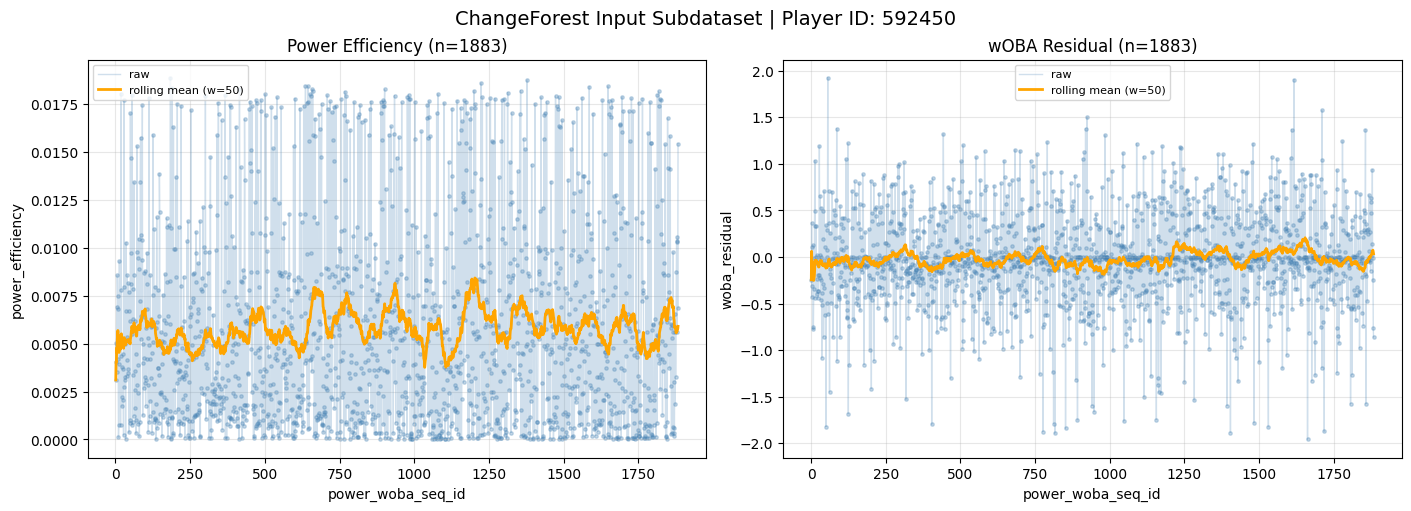

In [47]:
def changeforest_subdataset_generator(df, selected_player_id, window=50, min_periods=1):
    """
    Generate one aligned multivariate CPD subdataset for ChangeForest
    using power_efficiency + woba_residual.
    """
    base_cols = ["batter", "pa_uid", "game_date", "game_pk", "at_bat_number"]
    feature_cols = ["power_woba_seq_id", "power_efficiency", "woba_residual"]

    subdf = (
        df.loc[df["batter"] == selected_player_id, base_cols + feature_cols]
          .dropna(subset=["power_woba_seq_id", "power_efficiency", "woba_residual"])
          .sort_values("power_woba_seq_id")
          .reset_index(drop=True)
    )

    subdf[f"power_efficiency_rollmean_{window}"] = (
        subdf["power_efficiency"].rolling(window=window, min_periods=min_periods).mean()
    )
    subdf[f"woba_residual_rollmean_{window}"] = (
        subdf["woba_residual"].rolling(window=window, min_periods=min_periods).mean()
    )

    return subdf

def changeforest_subdataset_graph_generator(subdf, selected_player_id=None, window=50, figsize=(14, 5)):
    """
    Plot the 2 ChangeForest indicators as a 1x2 panel,
    showing raw signal and rolling mean.
    """
    plot_specs = [
        ("power_woba_seq_id", "power_efficiency", "Power Efficiency"),
        ("power_woba_seq_id", "woba_residual", "wOBA Residual"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    for ax, (x_col, y_col, title) in zip(axes, plot_specs):
        if subdf is None or subdf.empty:
            ax.set_title(f"{title} (no data)")
            ax.set_xlabel(x_col)
            ax.set_ylabel(y_col)
            ax.grid(alpha=0.3)
            continue

        smooth_col = f"{y_col}_rollmean_{window}"

        # raw
        ax.plot(subdf[x_col], subdf[y_col], linewidth=1.0, alpha=0.25,
                color="steelblue", label="raw")
        ax.scatter(subdf[x_col], subdf[y_col], s=6, alpha=0.3,
                   color="steelblue")

        # rolling mean
        if smooth_col in subdf.columns:
            ax.plot(subdf[x_col], subdf[smooth_col], linewidth=2.0,
                    color="orange", label=f"rolling mean (w={window})")

        ax.set_title(f"{title} (n={len(subdf)})")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle(
        "ChangeForest Input Subdataset"
        if selected_player_id is None
        else f"ChangeForest Input Subdataset | Player ID: {selected_player_id}",
        fontsize=14,
    )

    return fig, axes


# Example usage
subdf = changeforest_subdataset_generator(df, selected_player_id=592450, window=50)
fig, axes = changeforest_subdataset_graph_generator(subdf, selected_player_id=592450, window=50)
plt.show()

In [58]:
def run_changeforest(
    subdf,
    window=50,
    use_rollmean=True,
    standardize=True,
    minimal_relative_segment_length=0.05,
):
    """
    Run ChangeForest on one player's aligned 2-feature dataset.

    Fixed:
    ------
    model_selection_alpha = 0.02

    User can change:
    ----------------
    - window
    - minimal_relative_segment_length
    """
    if subdf is None or subdf.empty:
        return None, [], None, None

    if use_rollmean:
        feature_names = [
            f"power_efficiency_rollmean_{window}",
            f"woba_residual_rollmean_{window}",
        ]
    else:
        feature_names = [
            "power_efficiency",
            "woba_residual",
        ]

    X_used = subdf[feature_names].copy().values

    if standardize:
        X_used = StandardScaler().fit_transform(X_used)

    control = Control(
        model_selection_alpha=0.02,
        minimal_relative_segment_length=minimal_relative_segment_length,
    )

    result = changeforest(
        X_used,
        method="random_forest",
        control=control
    )

    cps = result.split_points()

    return result, cps, X_used, feature_names

def plot_changeforest_result(
    subdf,
    cps,
    window=50,
    use_rollmean=True,
    selected_player_id=None,
    minimal_relative_segment_length=None,
    figsize=(14, 5)
):
    """
    Plot ChangeForest result using game_date as X-axis (human-readable).
    """
    import matplotlib.dates as mdates

    if use_rollmean:
        y_cols = [
            f"power_efficiency_rollmean_{window}",
            f"woba_residual_rollmean_{window}",
        ]
    else:
        y_cols = [
            "power_efficiency",
            "woba_residual",
        ]

    titles = ["Power Efficiency", "wOBA Residual"]

    # Convert game_date to datetime for proper axis formatting
    dates = pd.to_datetime(subdf["game_date"])

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    for ax, y_col, title in zip(axes, y_cols, titles):
        ax.plot(dates, subdf[y_col], linewidth=1.8)

        # Change points → convert index → date
        for cp in cps:
            if 0 <= cp < len(subdf):
                cp_date = dates.iloc[cp]
                ax.axvline(
                    x=cp_date,
                    color="red",
                    linestyle="--",
                    alpha=0.8
                )

        ax.set_title(title)
        ax.set_xlabel("Game Date")
        ax.set_ylabel(y_col)
        ax.grid(alpha=0.3)

        # Format date axis
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.tick_params(axis="x", rotation=45)

    # Title
    main_title = "ChangeForest Result | alpha=0.02"
    if selected_player_id is not None:
        main_title += f" | Player ID: {selected_player_id}"
    if minimal_relative_segment_length is not None:
        main_title += f" | min_rel_seg_len={minimal_relative_segment_length}"
    main_title += f" | window={window}"

    fig.suptitle(main_title, fontsize=14)

    return fig, axes


Features used: ['power_efficiency_rollmean_50', 'woba_residual_rollmean_50']
Detected change points (no.): 14
Detected change points: [140, 245, 349, 447, 543, 639, 808, 993, 1167, 1304, 1437, 1561, 1691, 1786]
      power_woba_seq_id   game_date                 pa_uid
140               141.0  2021-06-06   2021_633812_592450_6
245               246.0  2021-08-04  2021_633018_592450_68
349               350.0  2021-09-15  2021_632494_592450_70
447               448.0  2022-04-28  2022_661305_592450_76
543               544.0  2022-06-08   2022_661681_592450_2
639               640.0  2022-07-21  2022_662775_592450_73
808               809.0  2022-10-20   2022_715737_592450_2
993               994.0  2023-08-29  2023_716795_592450_17
1167             1168.0  2024-05-15  2024_745908_592450_21
1304             1305.0  2024-07-22  2024_745717_592450_38
1437             1438.0  2024-09-24  2024_745688_592450_28
1561             1562.0  2025-04-30   2025_778115_592450_3
1691             1692.

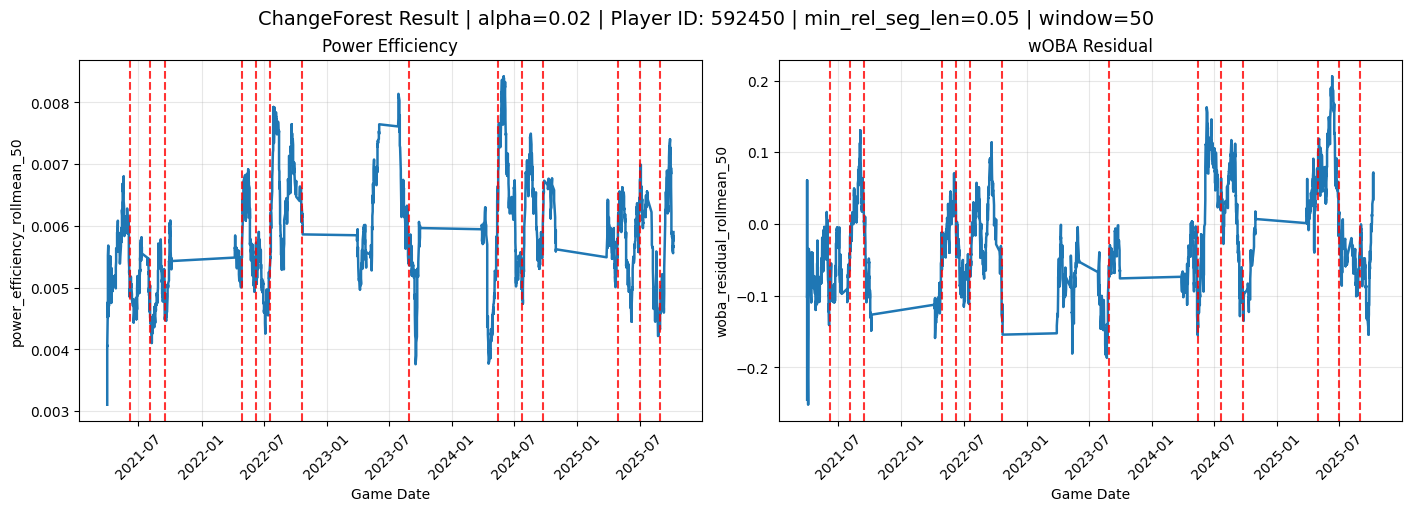

In [59]:
selected_player_id = 592450
window = 50
min_rel_seg_len = 0.05

subdf = changeforest_subdataset_generator(
    df,
    selected_player_id=selected_player_id,
    window=window
)

result, cps, X_used, feature_names = run_changeforest(
    subdf,
    window=window,
    use_rollmean=True,
    standardize=True,
    minimal_relative_segment_length=min_rel_seg_len
)

print("Features used:", feature_names)
print("Detected change points (no.):", len(cps))
print("Detected change points:", cps)

if len(cps) > 0:
    print(subdf.iloc[cps][["power_woba_seq_id", "game_date", "pa_uid"]])

fig, axes = plot_changeforest_result(
    subdf,
    cps,
    window=window,
    use_rollmean=True,
    selected_player_id=selected_player_id,
    minimal_relative_segment_length=min_rel_seg_len
)
plt.show()

### evaluate

In [63]:
# 1. Before vs After Statistical Difference
# We validate change points by comparing statistical properties before and after each detected point, ensuring significant shifts in mean or variance.
def evaluate_cp(subdf, cp, col):
    before = subdf[col].iloc[max(0, cp-50):cp]
    after = subdf[col].iloc[cp:cp+50]

    return {
        "mean_diff": after.mean() - before.mean(),
        "std_diff": after.std() - before.std()
    }

# 2. Robustness / Parameter Stability
for window in [30, 50, 80]:
    for min_rel_seg_len in [0.01, 0.05, 0.10]:
        subdf = changeforest_subdataset_generator(df, selected_player_id=592450, window=window)

        result, cps, X_used, feature_names = run_changeforest(
            subdf,
            window=window,
            minimal_relative_segment_length=min_rel_seg_len
        )

        print(
            f"window={window}, "
            f"minimal_relative_segment_length={min_rel_seg_len} "
            f"-> Detected change points (no.): {len(cps)}"
        )

# 3. Domain Validation
# idea: Do detected change points align with real baseball events?

window=30, minimal_relative_segment_length=0.01 -> Detected change points (no.): 70
window=30, minimal_relative_segment_length=0.05 -> Detected change points (no.): 13
window=30, minimal_relative_segment_length=0.1 -> Detected change points (no.): 6
window=50, minimal_relative_segment_length=0.01 -> Detected change points (no.): 72
window=50, minimal_relative_segment_length=0.05 -> Detected change points (no.): 14
window=50, minimal_relative_segment_length=0.1 -> Detected change points (no.): 6
window=80, minimal_relative_segment_length=0.01 -> Detected change points (no.): 69
window=80, minimal_relative_segment_length=0.05 -> Detected change points (no.): 13
window=80, minimal_relative_segment_length=0.1 -> Detected change points (no.): 5
